## **Overfitting vs Underfitting**

### **Underfitting**

**The model is too simple to capture the real pattern in the data.\
It performs badly on both training data and new data - it has not\
even learned the training set well.**

In [ ]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

df = pd.read_csv("smart_grid_stability_augmented.csv")
X = df.drop(columns=["stab", "stabf"])
y = df["stabf"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Underfit: extereme regularization forces coefficients near zero
# max_iter=10 too few iterations to converge

model = LogisticRegression(C=0.00001, max_iter=10)
model.fit(X_train, y_train)

print("Train acuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
print(classification_report(y_test, model.predict(X_test)))




# Fix Underfitting

# 1. Use a more powerful model
# from sklearn.ensemble import RandomForestClassifier
# model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Reduce regularization (increase C for LR, decrease alpha for Ridge)
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression(C=10)   # higher C = less regularization

# 3. Add more features / better feature engineering
# 4. Train for more iterations
# model = LogisticRegression(max_iter=1000)

# 5. Reduce dropout / regularization in neural networks


Train acuracy: 0.6403125
Test accuracy: 0.64275
              precision    recall  f1-score   support

      stable       1.00      0.01      0.02      4322
    unstable       0.64      1.00      0.78      7678

    accuracy                           0.64     12000
   macro avg       0.82      0.50      0.40     12000
weighted avg       0.77      0.64      0.51     12000



c:\Users\mrcoo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**The model predicts almost everything as one class - it never learned anything meaningful.\
Both train and test performance are close and both are poor.**

***Signs of underfitting:***
1. High training error
2. High validation error
3. Training and validation errors are similar(both bad)
4. Model produces nearly constant predictions

***Common causes:***
1. Model is too simple for the problem(Linear model on a non-linear relationship)
2. Too much regularization(very gigh alpha | very low C)
3. Too few training iterations(max_iter too low)
4. Too many features dropped or too much preprocessing 
5. Too little training data relative to problem complexity***



### **Overfitting**

**The model is too complex and memorizes the training data -\
including its noise and random quirks - instead of learning the\
underlying pattern. It performs very well on training data but\
poorly on new, unseen data.**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Overfit: no depth limit, tree will grow until every training sample is pure 

model_overfit = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1)
model_overfit.fit(X_train, y_train)

print("Train accuracy:", model_overfit.score(X_train, y_train))
print("Test accuracy:", model_overfit.score(X_test, y_test))

# large gap between train and test = overfitting


# Fix overfitting 


# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

# 1. Limit model complexity
# model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=10)

# 2. Add regularization
# from sklearn.linear_model import Ridge
# model = Ridge(alpha=10.0)   # higher alpha = more regularization

# 3. Get more training data (most reliable fix)

# 4. Use an ensemble — Random Forest averages many trees, reducing overfitting
# model = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=4)

# 5. Cross-validation to detect the problem early
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(model, X_train, y_train, cv=5)
# print(f"CV mean: {scores.mean():.3f}, std: {scores.std():.3f}")

# 6. Reduce features — remove irrelevant or redundant ones
# from sklearn.feature_selection import SelectKBest, f_classif
# selector = SelectKBest(f_classif, k=8)
# X_train_selected = selector.fit_transform(X_train, y_train)

Train accuracy: 1.0
Test accuracy: 0.89675


**The tree grew deep enough to perfectly memorize every training row.\
It scores 100% on training data but has poor generalization to new data\
because it learned the noise, not the signal.**

**Signs of overfitting:**
1. Very low training error 
2. High validation error
3. Large gap between train and test performance
4. Model performance degrades significantly on new data

**Common causes:**
1. Model is to complex(deep tree, many neurons, high-degree polynomial)
2. Not enough training data
3. Too little regularization 
4. Training for too many epochs(neural networks)
5. Including irrelevant features that let the model find spurious patterns


## **The Sweet Spot**

Neither underfit nor overfit. The model generalizes well - low training error\
and low validation error, with a small gap between them

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# testing different depths to find the sweet spot 

for depth in [2,4,6,8,10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_score = model.fit(X_train, y_train).score(X_train, y_train)
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy").mean()
    gap = train_score - cv_score
    print(f"max_depth={str(depth):5s} | train={train_score:.3f} | cv={cv_score:.3f} | gap={gap:.3f}")

# Output will show gap growing as depth increases
# The depth where cv_score peaks == sweet spot

max_depth=2     | train=0.696 | cv=0.689 | gap=0.008
max_depth=4     | train=0.775 | cv=0.767 | gap=0.009
max_depth=6     | train=0.847 | cv=0.835 | gap=0.012
max_depth=8     | train=0.888 | cv=0.867 | gap=0.020
max_depth=10    | train=0.936 | cv=0.885 | gap=0.051
max_depth=None  | train=1.000 | cv=0.889 | gap=0.111


**Bias-variance tradeoff (the theory behind it)**


*Overfitting and underfitting are two sides of a deeper idea called the bias-variance tradeoff:*

Total Error = Bias² + Variance + Irreducible Noise

    Bias is the error from wrong assumptions — a linear model applied\
    to a curved relationship will always miss, no matter how much data\ 
    you give it. High bias = underfitting.

    Variance is the error from sensitivity to small fluctuations in\ 
    training data — a very deep tree will learn a different structure \
    for each slightly different training set. High variance = overfitting.

    The tradeoff: making a model more complex reduces bias but increases variance. \
    The sweet spot minimizes their sum.


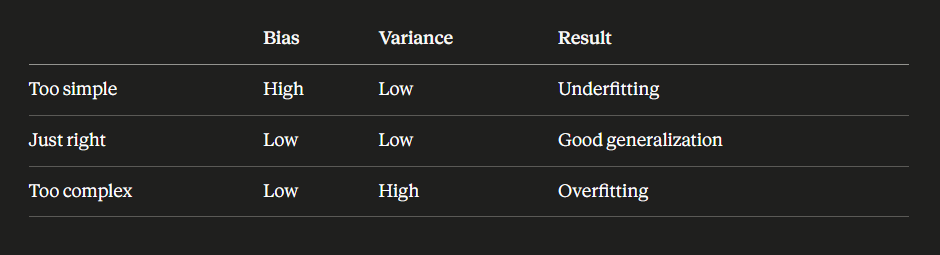